# Minimal no-rendering working memory demo  
__Run pre-recorded explorations, take features and encode them into a working memory using SSPs.__

Requirements: 

numpy  
opencv-python  
torch  
torchvision  
matplotlib  
scipy  
pillow  


In [1]:
import sys
import os
import numpy as np 
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import glob
import time
import cv2
from PIL import Image

from sspspace import sspspace

sys.path.append("semd_saliency_demo")
from rendering_and_visual_tools import show_animation, make_colorbar

### Memory structure

In [2]:
class WorkingMemory:
    """VSA-based working memory for saccade-based object learning."""
    def __init__(self, dino_model, dino_transform, dino_device, ssp_dim=384, MEMORY_GAMMA = 0.99, START_TSNE_COUNT = 10):
        np.random.seed(42)
        self.dino_model = dino_model
        self.dino_transform = dino_transform
        self.dino_device = dino_device
        self.ssp_dim = ssp_dim
        self.coord_encoder = sspspace.RandomSSPSpace(domain_dim=2, ssp_dim=ssp_dim)
        self.quat_encoder = sspspace.RandomSSPSpace(domain_dim=4, ssp_dim=ssp_dim)
        self.direction_encoder = sspspace.RandomSSPSpace(domain_dim=21*16, ssp_dim=ssp_dim)
        self.sensorimotor_update = np.zeros(self.ssp_dim, dtype=np.float32)
        self.memory = np.zeros(self.ssp_dim, dtype=np.float32)  
        self.dino_patch = np.zeros((1, ssp_dim))
        self.saccade_count = 0
        self.MEMORY_GAMMA = MEMORY_GAMMA
        self.START_TSNE_COUNT = START_TSNE_COUNT
        print(f"  Working Memory initialized (SSP dim: {ssp_dim})")

    def bind(self, a, b):
        a = np.asarray(a, dtype=np.complex64).reshape(-1)
        b = np.asarray(b, dtype=np.complex64).reshape(-1)
        assert a.shape == b.shape == (self.ssp_dim,) # make sure the shape is conserved
        # circular convolution in Fourier domain
        c = np.fft.ifft(np.fft.fft(a) * np.fft.fft(b)).real.astype(np.float32) #does it make sense to take real rather than abs in there? 
        return c
    
    def encode_sensorimotor_input(self, image_patch, rotation_state, direction_angles):
        #dino encoding
        image_patch_rgb = cv2.cvtColor(image_patch, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(image_patch_rgb)
        input_tensor = self.dino_transform(pil_image).unsqueeze(0).to(self.dino_device)
        with torch.no_grad():
            # DINO embedding (small model) is 1x384
            dino_embedding = self.dino_model(input_tensor).cpu().numpy().astype(np.float32)

        
        if dino_embedding.shape[1] < self.ssp_dim:
            padding = np.zeros((1, self.ssp_dim - dino_embedding.shape[1]))
            dino_embedding = np.hstack([dino_embedding, padding])
        else:
            dino_embedding = dino_embedding[:, :self.ssp_dim]
        dino_embedding = dino_embedding.reshape(-1)
        # normalize dino embedding so its norm is 1 + Fourier coeffs have norm 1:
        dino_embedding = to_unitary_ssp(dino_embedding, n=self.ssp_dim)
        self.dino_patch = dino_embedding
        
        quat_ssp = self.quat_encoder.encode([[rotation_state[0], rotation_state[1], rotation_state[2], rotation_state[3]]])[0]
        quat_ssp = quat_ssp.astype(np.float32)
        assert dino_embedding.shape == quat_ssp.shape == (self.ssp_dim,)

        direction_ssp = self.direction_encoder.encode([direction_angles.flatten()])[0]
        print(f"Direction ssp shape: {direction_ssp.shape}")
        
        # bind in role-filler manner
        bound_img_coord = self.bind(dino_embedding, quat_ssp)
        bound_representation = self.bind(bound_img_coord, direction_ssp)
        assert dino_embedding.shape == quat_ssp.shape == direction_ssp.shape == bound_representation.shape == (self.ssp_dim,)
        self.sensorimotor_update = bound_representation


    def update_memory(self):
        # TODO: can we do something more sophisticated than simple exponential moving average?
        #       sparse 3D representation by storing the different (protypical) views separately?
        assert self.memory.shape == self.sensorimotor_update.shape == (self.ssp_dim,)
        self.memory = self.MEMORY_GAMMA * self.memory + (1 - self.MEMORY_GAMMA) * self.sensorimotor_update
        self.saccade_count += 1
        return self.memory

    def get_memory(self):
        return self.memory.flatten()

    def reset_memory(self):
        self.memory = np.zeros((self.ssp_dim,)) 
        self.saccade_count = 0
        print("  Working memory reset")

def to_unitary_ssp(vec, n=None):
    v = vec.astype(np.float64).ravel()
    if n is None: n = v.size
    V = np.fft.rfft(v, n=n)
    V_unit = V / (np.abs(V) + 1e-9)        # unit magnitude per bin
    u = np.fft.irfft(V_unit, n=n)
    u /= (np.linalg.norm(u) + 1e-9)         
    return u


### Initialization

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

WIDTH, HEIGHT = 346, 260
RADIUS = 17 # for 1% of field of view area
SSP_DIM = 384
MEMORY_GAMMA = 0.99999 # decay factor for working memory

# init DINO model
dino_device = torch.device("cpu") # DINO on CPU
dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False).to(dino_device)
dino_model.eval()
dino_transform = T.Compose([
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224), T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


/Users/sarkaliskova/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/sarkaliskova/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/sarkaliskova/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


### Select object: apple, fish, banana  
__Available seeds: 0, 2, 3__  

All of the pre-recorded explorations consist from 100 exploratory steps.

In [4]:
obj_name = "apple"
seed = 3
data_path = f"object_exploration_data/{obj_name}"

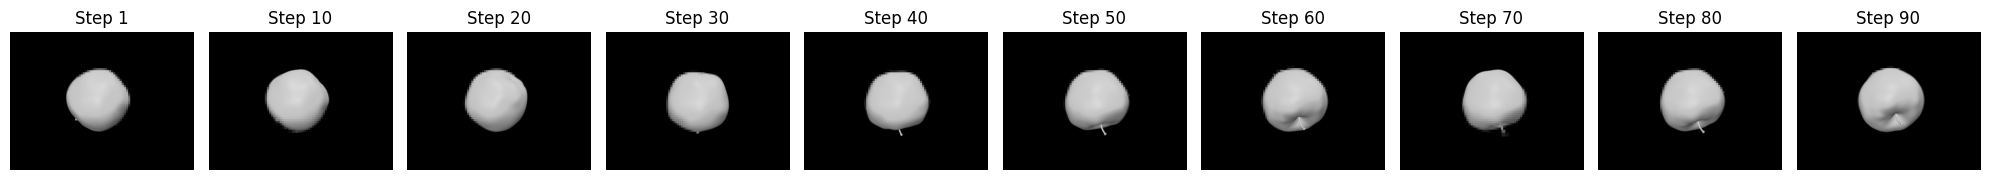

In [5]:
steps_to_show = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90]

fig, axes = plt.subplots(1, len(steps_to_show), figsize=(20, 3))

for ax, step in zip(axes, steps_to_show):
    file_path = os.path.join(data_path, f"{obj_name}_export_seed{seed}_step{step}.npz")
    try:
        data = np.load(file_path)
        # Display the grayscale image 
        img = data['foveated_gray']
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Step {step}")
    except Exception as e:
        ax.set_title(f"Step {step}\n(missing)")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Run exploration (from saved data)

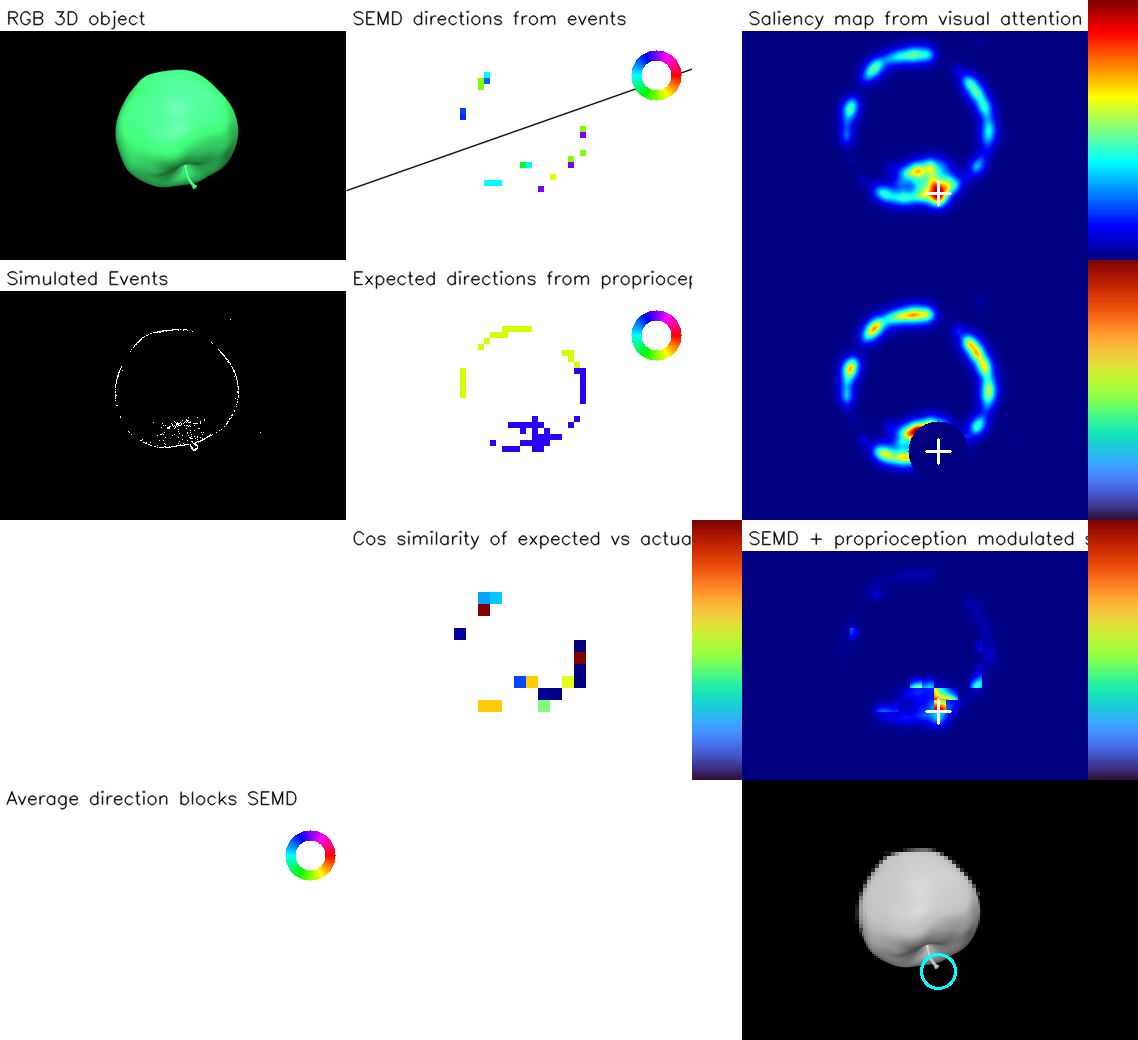

KeyboardInterrupt: 

In [6]:
object_name = obj_name

# Find how many steps we have
files = glob.glob(os.path.join(data_path, f"{object_name}_export_seed{seed}_step*.npz"))
num_steps = len(files)

memory = WorkingMemory(dino_model, dino_transform, dino_device, ssp_dim=SSP_DIM)

for i in range(1, num_steps + 1):
    file_path = os.path.join(data_path, f"{object_name}_export_seed{seed}_step{i}.npz")
    if not os.path.exists(file_path):
        continue
        
    data = np.load(file_path)
    
    foveated_gray = data['foveated_gray']
    rot_rel = data['rot_rel']
    direction_angles = data['averaged_angles']
    
    # 1. Update memory based on the inputs
    memory.encode_sensorimotor_input(foveated_gray, rot_rel, direction_angles) #using DINO encoding 
    current_memory_trace = memory.sensorimotor_update # memory update from the current step
    mem = memory.update_memory() # sum over time of all the previous memory steps = currennt memory
    print(f"\n Object: {object_name}, Seed:{seed}, step: {i}/{num_steps}")

    # save the memory traces

    os.makedirs(f"VSA_memories/step_updates/{object_name}", exist_ok=True)
    np.save(f"VSA_memories/step_updates/{object_name}/{object_name}_memory_seed{seed}_step{i}.npy", current_memory_trace)

    os.makedirs(f"VSA_memories/summed_memories/{object_name}", exist_ok=True)
    np.save(f"VSA_memories/summed_memories/{object_name}/{object_name}_memory_seed{seed}_step{i}.npy", mem)

    # 2. Show the animation/visualization
    if i > 1:
        show_animation(
            data['cropped_rgb'], 
            data['ev_img'], 
            data['saliency'], 
            data['inhibited_saliency'], 
            data['foveated_color'], 
            RADIUS, 
            data['most_sal_point'][1], 
            data['most_sal_point'][0], 
            data['speed_vis'], 
            data['expected_angles_block'], 
            data['surprise'], 
            data['sal_mod_vis'], 
            data['downsampled_angles_block'], 
            data['next_fixation'], 
            HEIGHT, 
            WIDTH
        )
        time.sleep(0.01) # Small pause to allow visualization update
